In [ ]:
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/data/Advertising Budget and Sales.csv')

df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Data Preperation

In [ ]:
df = df.rename(columns={"Sales ($)": "Sales(Units)"})

df.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales(Units)'],
      dtype='object')

In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Missing Values:")
print(df.isnull().sum())

df = df.drop_duplicates()

df.info()

Missing Values:
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales(Units)               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales(Units)             200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Data Engineering

In [ ]:
# Creating total advertising budget column

df["Total_Ad_Budget"] = (
    df["TV Ad Budget ($)"] +
    df["Radio Ad Budget ($)"] +
    df["Newspaper Ad Budget ($)"]
)

df = df.round(1)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


this column will allow me to see what each company is spending on all three ad budgets. this is probably the most important added column because of the amount of things I need to know what the total for all of these ad budgets.

In [ ]:
# creating a channel share columns for each ad

df["TV_Share(%)"] = df["TV Ad Budget ($)"] / df["Total_Ad_Budget"]
df["Radio_Share(%)"] = df["Radio Ad Budget ($)"] / df["Total_Ad_Budget"]
df["Newspaper_Share(%)"] = df["Newspaper Ad Budget ($)"] / df["Total_Ad_Budget"]

# round share columns and make them percentages

share_cols = ["TV_Share(%)", "Radio_Share(%)", "Newspaper_Share(%)"]

df[share_cols] = (df[share_cols] * 100).round(2)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget,TV_Share(%),Radio_Share(%),Newspaper_Share(%)
0,230.1,37.8,69.2,22.1,337.1,68.26,11.21,20.53
1,44.5,39.3,45.1,10.4,128.9,34.52,30.49,34.99
2,17.2,45.9,69.3,9.3,132.4,12.99,34.67,52.34
3,151.5,41.3,58.5,18.5,251.3,60.29,16.43,23.28
4,180.8,10.8,58.4,12.9,250.0,72.32,4.32,23.36


These three columns will help me see which ad budget has the most money  invested in them, which will help me with answering my specific question which channel has the most influence on volume?

In [ ]:
# making a sales effciency column

df["Sales_per_Dollar"] = df["Sales(Units)"] / df["Total_Ad_Budget"]

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget,TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar
0,230.1,37.8,69.2,22.1,337.1,68.26,11.21,20.53,0.065559
1,44.5,39.3,45.1,10.4,128.9,34.52,30.49,34.99,0.080683
2,17.2,45.9,69.3,9.3,132.4,12.99,34.67,52.34,0.070242
3,151.5,41.3,58.5,18.5,251.3,60.29,16.43,23.28,0.073617
4,180.8,10.8,58.4,12.9,250.0,72.32,4.32,23.36,0.051600


This will help me with answer one of my specific questions, what is the marginal increase in units sold for every $10,000 spent?


In [ ]:
new_order = [
    "TV Ad Budget ($)",
    "Radio Ad Budget ($)",
    "Newspaper Ad Budget ($)",
    "TV_Share(%)",
    "Radio_Share(%)",
    "Newspaper_Share(%)",
    "Sales_per_Dollar",
    "Total_Ad_Budget",
    "Sales(Units)"
]

df = df[new_order]

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units)
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9


I had to reorder the columns because it makes the dataset easier to read and it looks a lot more organized when it is order like this.

In [ ]:
df.to_csv("f_clean_advertising.csv", index=False)

In [ ]:
from google.colab import files
files.download("f_clean_advertising.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("f_clean_advertising.csv")

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units)
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9


## TV advertising Vs. Sales

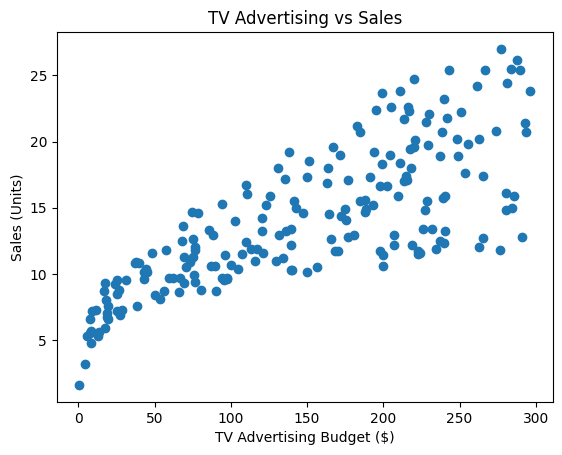

In [ ]:
plt.figure()

plt.scatter(df["TV Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("TV Advertising vs Sales")

plt.show()

## Radio Advertising Vs. Sales

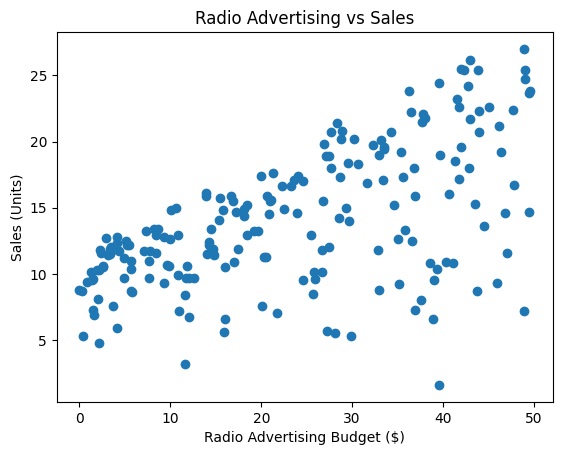

In [ ]:
plt.figure()

plt.scatter(df["Radio Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("Radio Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("Radio Advertising vs Sales")

plt.show()

## Newspaper advertising Vs. Sales

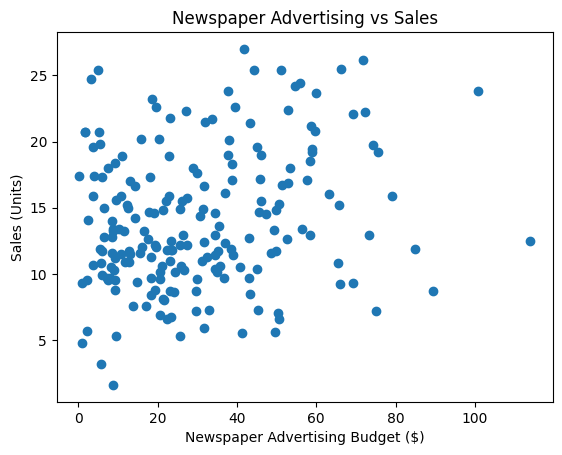

In [ ]:
plt.figure()

plt.scatter(df["Newspaper Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("Newspaper Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("Newspaper Advertising vs Sales")

plt.show()

explanation:

The exploratory analysis suggests that TV advertising has the strongest relationship with sales, followed by radio advertising. Newspaper advertising appears to have a weaker relationship with sales. This suggests that TV and radio advertising may be more important predictors when building a sales prediction model.

## Tv spend level

In [ ]:
df["TV_spend_level"] = pd.qcut(
    df["TV Ad Budget ($)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units),TV_spend_level
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1,High
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4,Low
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3,Low
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5,Medium
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9,Medium


I decided to try and see if making levels for spending will help any analysis I do.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"]]
y = df["Sales(Units)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))


R2 Score: 0.899438024100912
MAE: 1.4607567168117603


explanation:

The initial linear regression model was created for the prediction of sales using advertising budgets for TV, radio, and newspaper advertising channels. The initial linear regression model showed a good R² value, implying that advertising spending was the major driver of sales. Among the advertising channels, the TV advertising channel was the most influential for the predicted sales. The least influential advertising channel was the newspaper advertising channel.



In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)


dt_r2 = r2_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)

print("Decision Tree R2:", dt_r2)
print("Decision Tree MAE:", dt_mae)

Decision Tree R2: 0.9310914968293178
Decision Tree MAE: 0.9850000000000001


Explanation:

I decided to use the decision tree regressor to add more relalistic patterns in my project. Unlike the linear regression, this adds simple rules into the project like "if tv sales is high then sales is high". this gives this project a more human like approach to the project.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)


rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest R2:", rf_r2)
print("Random Forest MAE:", rf_mae)

Random Forest R2: 0.9812843792541843
Random Forest MAE: 0.6200999999999988


Explanation:

the random forest regressor is an upgraded version of the decision tree by making many decision trees instead of just one tree. It then combines the trees to come up with a more accurate prediction. the multiple trees also reduces the amount of errors in the prediction.

In [ ]:

from sklearn.metrics import mean_absolute_error, r2_score

results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2": [
        r2_score(y_test, predictions),
        r2_score(y_test, dt_preds),
        r2_score(y_test, rf_preds)
    ],
    "MAE": [
        mean_absolute_error(y_test, predictions),
        mean_absolute_error(y_test, dt_preds),
        mean_absolute_error(y_test, rf_preds)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2       MAE
0  Linear Regression  0.899438  1.460757
1      Decision Tree  0.931091  0.985000
2      Random Forest  0.981284  0.620100


this showed that the random forest section is by far the best for the MAE and the best model for my R2. this is not that suprising to me as random forest is an upgraded version of the decision tree. so I will be using random forest to do my research.

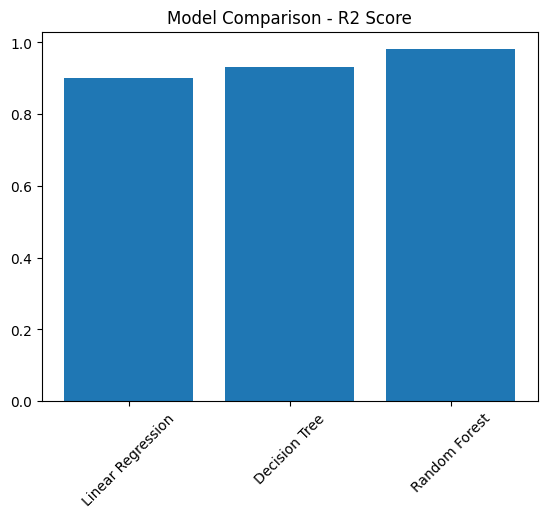

In [ ]:

plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison - R2 Score")
plt.xticks(rotation=45)
plt.show()

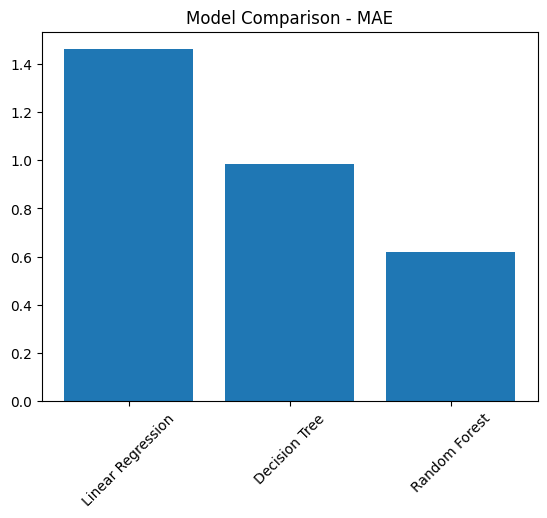

In [ ]:

plt.figure()
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison - MAE")
plt.xticks(rotation=45)
plt.show()

## Research on answering my business Questions

In [ ]:
import numpy as np

results = []

increase_amount = 10

for i, channel in enumerate(X.columns):
    increases = []

    for idx in range(len(X)):
        base_point = X.iloc[[idx]].copy()
        test_point = base_point.copy()

        test_point.iloc[0, i] += increase_amount

        base_pred = rf_model.predict(base_point)[0]
        new_pred = rf_model.predict(test_point)[0]

        increases.append(new_pred - base_pred)

    avg_increase = np.mean(increases) * (10000 / increase_amount)

    results.append({
        "Channel": channel,
        "Sales Increase per $10,000": avg_increase
    })

results_df = pd.DataFrame(results).sort_values(
    by="Sales Increase per $10,000", ascending=False
)

print(results_df)

                   Channel  Sales Increase per $10,000
1      Radio Ad Budget ($)                    1475.905
0         TV Ad Budget ($)                     446.605
2  Newspaper Ad Budget ($)                      52.020


Explinatiion:

For this part, I was very suprised that radio ads is so much higher in this categoory, but radio is the "turbo" of the three categories which if you put money into all three, you'd get the most immediate affect from radio ads.

In [ ]:
importance_df = pd.DataFrame({
    "Channel": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                   Channel  Importance
0         TV Ad Budget ($)    0.624810
1      Radio Ad Budget ($)    0.362201
2  Newspaper Ad Budget ($)    0.012989


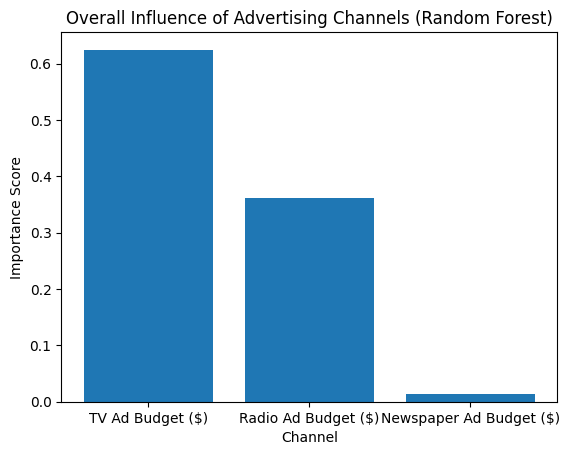

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(importance_df["Channel"], importance_df["Importance"])
plt.title("Overall Influence of Advertising Channels (Random Forest)")
plt.xlabel("Channel")
plt.ylabel("Importance Score")
plt.show()


In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Channel": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df)

                   Channel  Importance
0         TV Ad Budget ($)    1.486394
1      Radio Ad Budget ($)    0.542192
2  Newspaper Ad Budget ($)    0.000059


In [ ]:

df = pd.read_csv("f_clean_advertising.csv")

df["TV_Level"] = pd.qcut(df["TV Ad Budget ($)"], q=3, labels=["Low", "Medium", "High"])
df["Radio_Level"] = pd.qcut(df["Radio Ad Budget ($)"], q=3, labels=["Low", "Medium", "High"])
df["Newspaper_Level"] = pd.qcut(df["Newspaper Ad Budget ($)"], q=3, labels=["Low", "Medium", "High"])

df["Sales_per_Dollar"] = df["Sales(Units)"] / df["Total_Ad_Budget"]

def efficiency_by_level(df, level_col):
    return (
        df.groupby(level_col, observed=False)["Sales_per_Dollar"]
        .mean()
        .reset_index()
        .rename(columns={"Sales_per_Dollar": "Avg_Efficiency"})
        .sort_values("Avg_Efficiency", ascending=False)
    )

tv_eff = efficiency_by_level(df, "TV_Level")
radio_eff = efficiency_by_level(df, "Radio_Level")
news_eff = efficiency_by_level(df, "Newspaper_Level")

print("TV Spend Level Efficiency:")
print(tv_eff, "\n")

print("Radio Spend Level Efficiency:")
print(radio_eff, "\n")

print("Newspaper Spend Level Efficiency:")
print(news_eff)

TV Spend Level Efficiency:
  TV_Level  Avg_Efficiency
0      Low        0.102306
1   Medium        0.072748
2     High        0.061049 

Radio Spend Level Efficiency:
  Radio_Level  Avg_Efficiency
0         Low        0.079763
1      Medium        0.078443
2        High        0.077963 

Newspaper Spend Level Efficiency:
  Newspaper_Level  Avg_Efficiency
0             Low        0.090108
1          Medium        0.078013
2            High        0.067881


/tmp/ipykernel_3934/2391428910.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = combined.pivot_table(


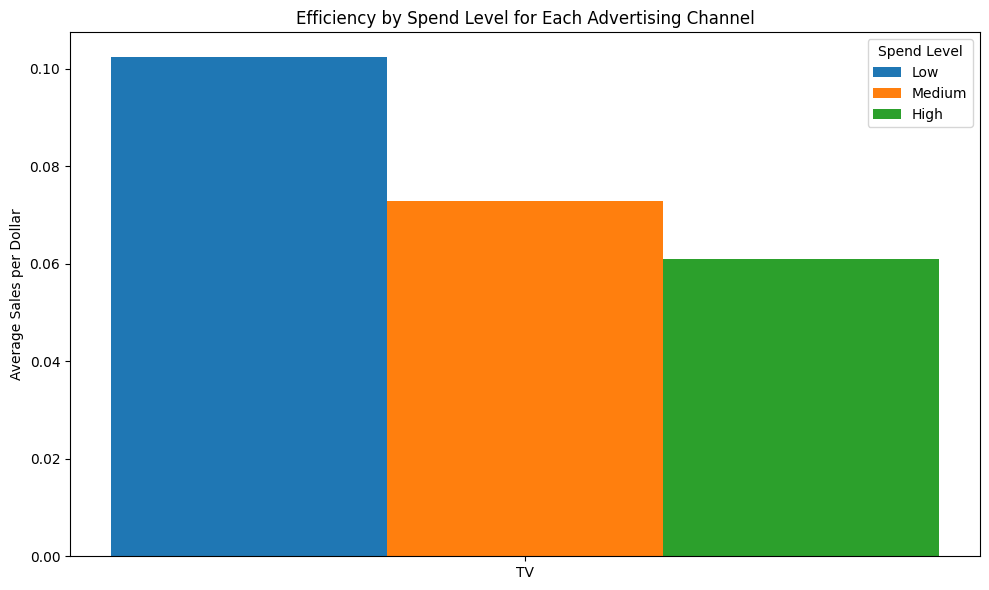

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine efficiency tables
tv_eff["Channel"] = "TV"
radio_eff["Channel"] = "Radio"
news_eff["Channel"] = "Newspaper"

combined = pd.concat([tv_eff, radio_eff, news_eff])

# FIXED: use pivot_table instead of pivot
pivot_df = combined.pivot_table(
    index="Channel",
    columns=combined.columns[0],
    values="Avg_Efficiency",
    aggfunc="mean"
)

# Plot grouped bar chart
plt.figure(figsize=(10, 6))

levels = pivot_df.columns
x = np.arange(len(pivot_df.index))
width = 0.25

for i, level in enumerate(levels):
    plt.bar(x + i*width, pivot_df[level], width, label=level)

plt.xticks(x + width, pivot_df.index)
plt.ylabel("Average Sales per Dollar")
plt.title("Efficiency by Spend Level for Each Advertising Channel")
plt.legend(title="Spend Level")
plt.tight_layout()
plt.show()

Explanation:

This efficiency scale shows how well each spending level (Low, Medium, High) converts advertising dollars into actual units sold. The point of this metric is to compare which group gets the most sales for every dollar invested, helping identify where the company’s money works hardest. Higher numbers mean that level is generating more units per dollar spent, while lower numbers show less efficient use of the advertising budget.










Explaination:

with these two different importance factors (permutation importance and importance by %) I found that the TV ad budget is by far the most important channel for increasing volume. it also makes sense as most of the companies that didn't spend the most money on TV ad budget had on average a lot lower of a unit sales.

Full project explanation:

After completing my analysis, I found that TV advertising is the strongest overall driver of sales, and it’s the channel I would invest the most money into. The Random Forest model, which ended up being my most accurate model with an R² of 0.98, showed that TV ads make up about 62% of the total influence on sales. That means TV consistently has the biggest long‑term impact and is the most reliable channel for increasing units sold.

Radio advertising performed differently. Even though radio gave the highest marginal increase per $10,000 spent, it didn’t have the same overall importance as TV. Radio acts more like a short‑term boost — it spikes sales quickly, but it doesn’t carry the same long‑term weight. Because of that, I would still put most of the budget into TV and then use radio as a secondary channel when the business needs a fast lift in demand. Newspaper advertising was clearly the weakest performer, with almost no influence on sales and the smallest return on additional spending, so I wouldn’t recommend putting much budget there. I also found out after making company ranges of high medium and low that low are the most effiecent on all three advertisments and medium is second most effiecient on all of these advertisments as well.

This project can be useful for a wide range of companies. Any business that relies on advertising to drive product sales could use this type of analysis to make smarter budget decisions. For example, consumer goods companies, retail brands, automotive companies, food and beverage brands, and even local businesses that run regional ad campaigns could all benefit from knowing which channels give them the best return. Marketing teams, advertising agencies, and media planners could also use this kind of model to justify where they allocate their clients’ budgets. Basically, any company that spends money on TV, radio, or newspaper ads could use this project to understand which channels are worth investing in and which ones aren’t delivering enough value.

Overall, this project helps answer several important business questions. It shows which advertising channel has the biggest impact on sales, how much sales increase when spending goes up, and which channels are worth investing in. It also shows how accurately we can predict sales based on advertising budgets and helps guide decisions about where a company should allocate its marketing dollars. By combining the model results with the exploratory analysis, the project gives a clear, data‑driven recommendation: focus on TV for consistent growth, use radio for quick boosts, and avoid overspending on newspaper ads.